In [2]:
# Classification

In [3]:
import pandas as pd

# Student dataset
data = {
    "Hours_Studied": [1,2,2,3,3,4,4,5,5,6,
                      6,7,7,8,8,9,9,10,10,11],
    "Attendance": [50,55,60,58,65,62,70,68,75,72,
                    78,80,82,85,88,90,92,94,96,98],
    "Pass": [0,0,0,0,0,0,0,1,1,1,
             1,1,1,1,1,1,1,1,1,1]
}
df = pd.DataFrame(data)
print(df)

    Hours_Studied  Attendance  Pass
0               1          50     0
1               2          55     0
2               2          60     0
3               3          58     0
4               3          65     0
5               4          62     0
6               4          70     0
7               5          68     1
8               5          75     1
9               6          72     1
10              6          78     1
11              7          80     1
12              7          82     1
13              8          85     1
14              8          88     1
15              9          90     1
16              9          92     1
17             10          94     1
18             10          96     1
19             11          98     1


In [4]:
from sklearn.model_selection import train_test_split
X = df[["Hours_Studied","Attendance"]]
y = df["Pass"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)
print("X train:",X_train)
print("\n X test:",X_test)
print("\n y Train:",y_train)
print("\n y Test:",y_test)

X train:     Hours_Studied  Attendance
14              8          88
5               4          62
15              9          90
8               5          75
10              6          78
18             10          96
2               2          60
0               1          50
9               6          72
17             10          94
7               5          68
12              7          82
1               2          55
4               3          65

 X test:     Hours_Studied  Attendance
3               3          58
13              8          85
6               4          70
11              7          80
19             11          98
16              9          92

 y Train: 14    1
5     0
15    1
8     1
10    1
18    1
2     0
0     0
9     1
17    1
7     1
12    1
1     0
4     0
Name: Pass, dtype: int64

 y Test: 3     0
13    1
6     0
11    1
19    1
16    1
Name: Pass, dtype: int64


In [5]:
## Logistic Regression

Actual: [0 1 0 1 1 1]
Predicted: [0 1 1 1 1 1]

Accuracy: 0.8333333333333334

 Confusion Matrix: [[1 1]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



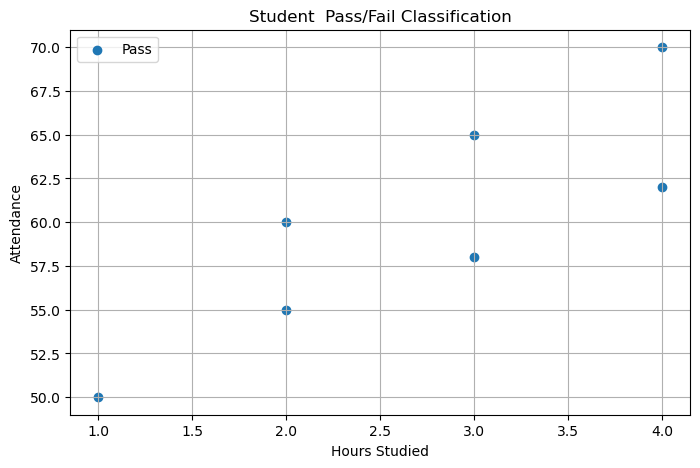

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model
model = LogisticRegression()

#Training 
model.fit(X_train_scaled, y_train)

#Predictions
y_pred = model.predict(X_test_scaled)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\nAccuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

#Graph
plt.figure(figsize=(8,5))
plt.scatter(df[df["Pass"] ==0]
               ["Hours_Studied"],
            df[df["Pass"] ==0]
               ["Attendance"],
            label="Pass")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student  Pass/Fail Classification")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Model
model = DecisionTreeClassifier(max_depth=3,random_state=42)

#Training
model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\n Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 0 1 1 1]

 Accuracy: 1.0

 Confusion matrix: [[2 0]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



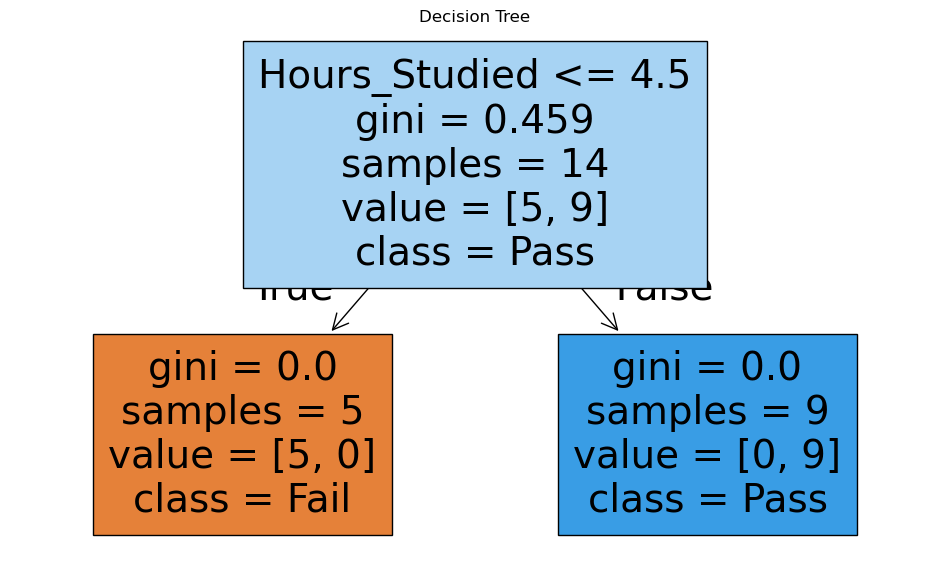

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(12,7))
plot_tree(model,feature_names=["Hours_Studied","Attendance"],
          class_names=["Fail","Pass"],
          filled=True)
plt.title("Decision Tree")
plt.show()

In [10]:
## Random Forest 

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Model
model=RandomForestClassifier(n_estimators=100,random_state=42)

#Training 
model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 1 1 1 1]
Accuracy: 0.8333333333333334

 Confusion Matrix: [[1 1]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



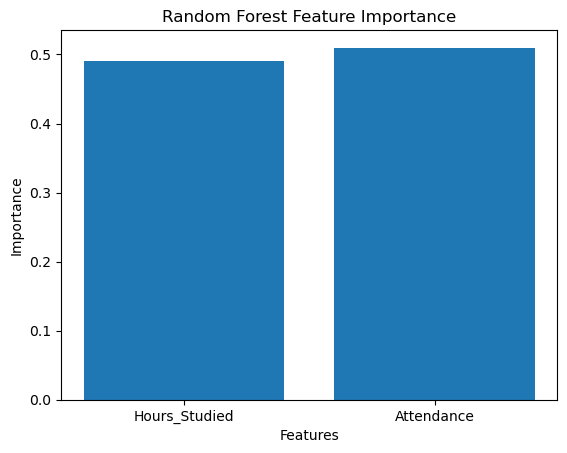

In [12]:
##Graph
import matplotlib.pyplot as plt
importance = model.feature_importances_
plt.bar(["Hours_Studied","Attendance"],importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [13]:
## KNN

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Model
model = KNeighborsClassifier(n_neighbors=5)

#Training
model.fit(X_train_scaled,y_train)

#Prediction
y_pred = model.predict(X_test_scaled)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\n Accuarcy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 1 1 1 1]

 Accuarcy: 0.8333333333333334

 Confusion Matrix: [[1 1]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



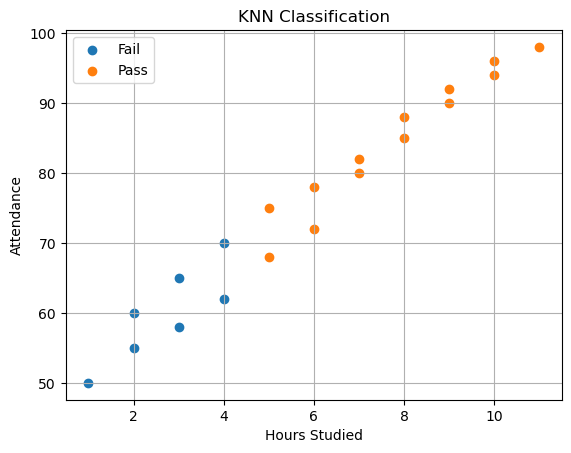

In [15]:
## Graph
plt.scatter(df[df["Pass"] ==0]
            ["Hours_Studied"],
            df[df["Pass"]==0]
            ["Attendance"],
            label="Fail")
plt.scatter(df[df["Pass"]==1]
            ["Hours_Studied"],
            df[df["Pass"]==1]
            ["Attendance"],
            label="Pass")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("KNN Classification")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# SVM

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform (X_train)
X_test_scaled = scaler.transform(X_test)

#Model
model = SVC(kernel="rbf",C=1.0)

#Training
model.fit(X_train_scaled,y_train)

#Prediction
y_pred=model.predict(X_test_scaled)

#Results
print("Actual:",y_test.values)
print("Prdicted:",y_pred)

print("\n Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Prdicted: [0 1 1 1 1 1]

 Accuracy: 0.8333333333333334

 Confusion Matrix: [[1 1]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



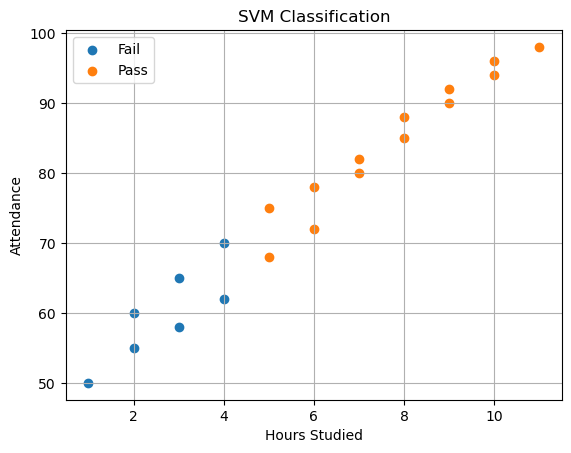

In [18]:
##Graph
plt.scatter(df[df["Pass"]==0]
            ["Hours_Studied"],
            df[df["Pass"]==0]
            ["Attendance"]
        ,   label="Fail")
plt.scatter(df[df["Pass"]==1]
            ["Hours_Studied"],
            df[df["Pass"]==1]
            ["Attendance"],
            label="Pass")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("SVM Classification")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Naive Bayes 

In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Model
model = GaussianNB()

# Training
model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\n Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 1 1 1 1]

 Accuracy: 0.8333333333333334

 Confusion matrix: [[1 1]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.80      1.00      0.89         4

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6



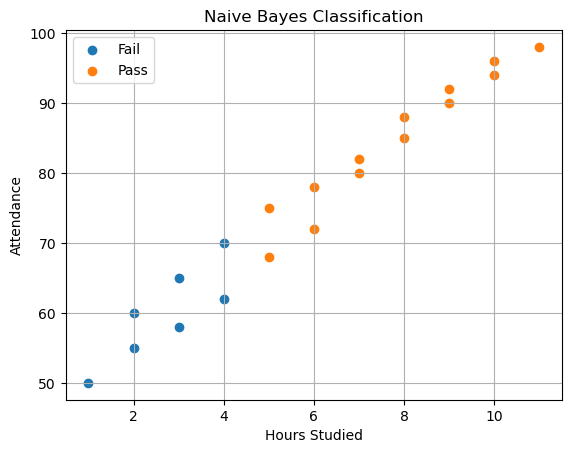

In [22]:
##Graph
plt.scatter(df[df["Pass"]==0]
            ["Hours_Studied"],
            df[df["Pass"]==0]
            ["Attendance"],
            label="Fail")
plt.scatter(df[df["Pass"]==1]
            ["Hours_Studied"],
            df[df["Pass"]==1]
            ["Attendance"],
            label="Pass")
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Naive Bayes Classification")
plt.legend()
plt.grid(True)
plt.show()
            
            

In [23]:
# Gradient Boosting 

In [24]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

#Model
model=GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)

#Training
model.fit(X_train,y_train)

#Prediction
y_pred=model.predict(X_test)

#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\n Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 0 1 1 1]

 Accuracy: 1.0

 Confusion Matrix: [[2 0]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



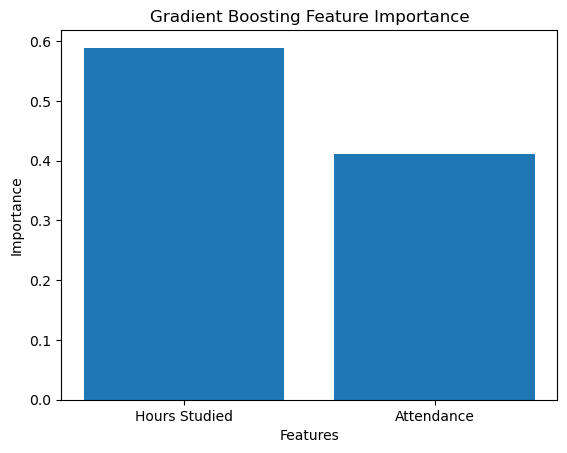

In [25]:
##Graph
plt.bar(["Hours Studied","Attendance"],
        model.feature_importances_ )
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Gradient Boosting Feature Importance")
plt.show()

In [26]:
# XG Boost

In [28]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 2.9/48.9 MB 16.6 MB/s eta 0:00:03
   ----- ---------------------------------- 6.8/48.9 MB 18.0 MB/s eta 0:00:03
   ------- -------------------------------- 9.7/48.9 MB 16.5 MB/s eta 0:00:03
   ---------- ----------------------------- 12.6/48.9 MB 15.9 MB/s eta 0:00:03
   ------------- -------------------------- 16.0/48.9 MB 15.9 MB/s eta 0:00:03
   ---------------- ----------------------- 19.9/48.9 MB 16.4 MB/s eta 0:00:02
   ------------------ --------------------- 22.8/48.9 MB 16.1 MB/s eta 0:00:02
   -------------------- ------------------- 25.7/48.9 MB 15.9 MB/s eta 0:00:02
   ----------------------- ---------------- 28.8/48.9 MB 15.7 MB/s eta 0:00:02
   -------------------------- ------------- 32.8/48.9 MB 16.1 MB/s eta 0:00:02
   ----------------------------- ---------- 36.7/48.9 MB 16.4 MB/s eta 0:00:01
   -------------------------------- ------- 40.1/48.9 MB 16.5 MB

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
#model 
model=XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42,eval_metric="logloss")
#Training
model.fit(X_train,y_train)
#Prediction
y_pred=model.predict(X_test)
#Results
print("Actual:",y_test.values)
print("Predicted:",y_pred)

print("\n Accuracy:",accuracy_score(y_test,y_pred))
print("\n Confusion Matrix:",confusion_matrix(y_test,y_pred))
print("\n Classification Report:",classification_report(y_test,y_pred))

Actual: [0 1 0 1 1 1]
Predicted: [0 1 0 1 1 1]

 Accuracy: 1.0

 Confusion Matrix: [[2 0]
 [0 4]]

 Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



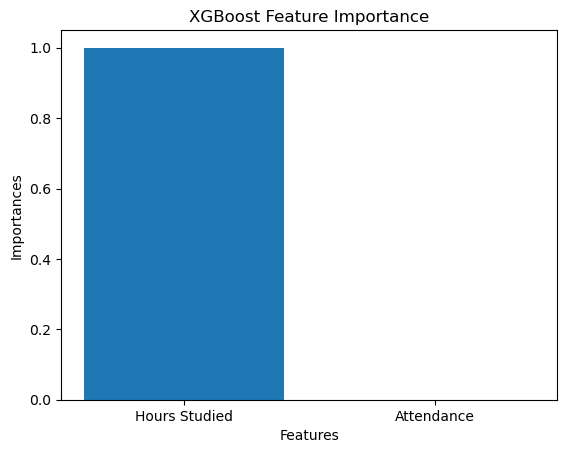

In [31]:
##Graph 
plt.bar(["Hours Studied","Attendance"],model.feature_importances_ )
plt.xlabel("Features")
plt.ylabel("Importances")
plt.title("XGBoost Feature Importance")
plt.show()